## Preprocessing

In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import skimage.io
import json
from pathlib import Path

ROOT_DIR = Path().resolve().parent
sys.path.append(str(ROOT_DIR))

import importlib
import utils.preprocessing
importlib.reload(utils.preprocessing)


from utils.preprocessing import (load_coco_annotations, 
                                 coco_seg_to_mask, 
                                 count_teeth_per_image, 
                                 build_masks,
                                 preprocess_directory,
                                 load_image,
                                 split_coco_dataset)
from utils.visualization import apply_masks

DATA_DIR = ROOT_DIR / 'data'
IMG_DIR  = DATA_DIR / 'images'
ANN_DIR  = DATA_DIR / 'annotations'
PROC_DIR = DATA_DIR / 'processed'
VIZ_DIR  = ROOT_DIR / 'outputs' / 'visualizations'


Preprocessing 333 images → /home/dorina/Downloads/dental-segmentation-v3/dental-segmentation/data/processed
Done.
333 preprocessed images saved!


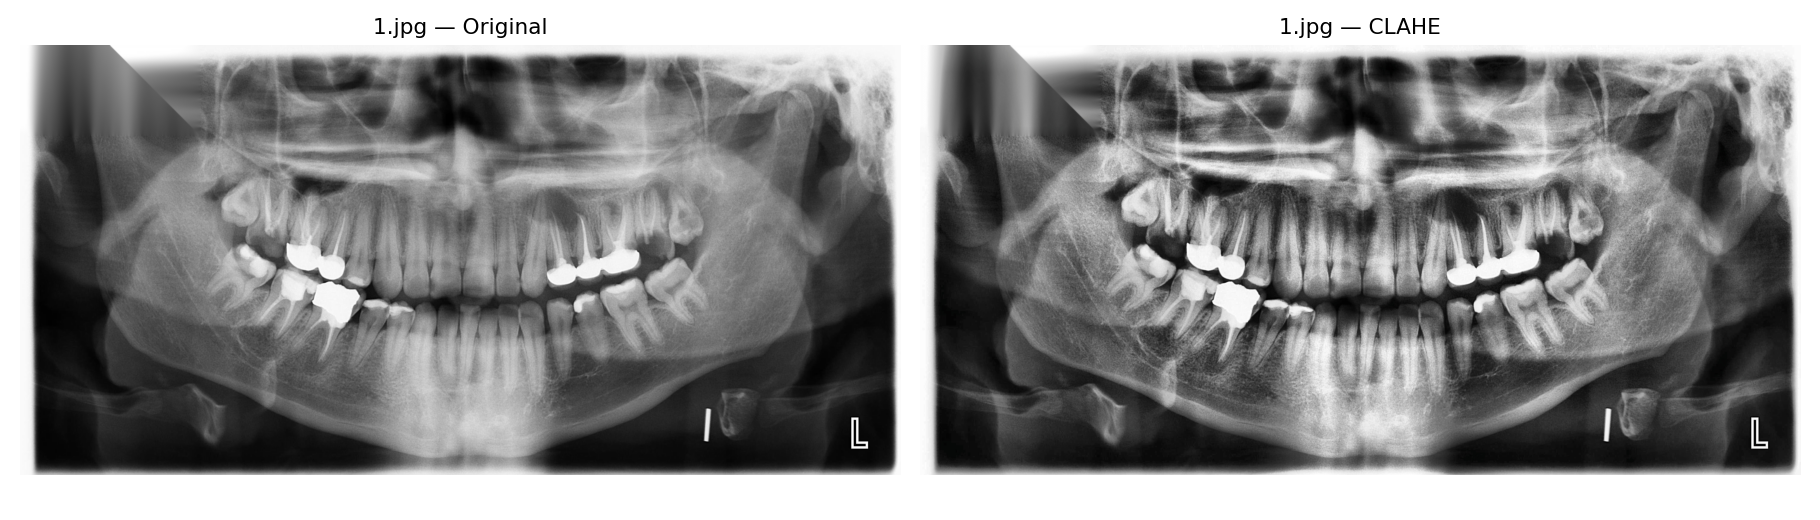

Train: 266 images, 7922 annotations
Val:   67 images, 2034 annotations


In [2]:
# Apply CLAHE to all 333 images → save to data/processed/
preprocess_directory(str(IMG_DIR), str(PROC_DIR))

processed = list(PROC_DIR.glob("*.jpg"))
print(f"{len(processed)} preprocessed images saved!")

# Visual check — before vs after CLAHE
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fname = '1.jpg'
axes[0].imshow(load_image(str(IMG_DIR  / fname)), cmap='gray')
axes[0].set_title(f'{fname} — Original')
axes[0].axis('off')
axes[1].imshow(load_image(str(PROC_DIR / fname)), cmap='gray')
axes[1].set_title(f'{fname} — CLAHE')
axes[1].axis('off')
plt.tight_layout()
plt.savefig(VIZ_DIR / 'clahe_comparison.png', dpi=130)
plt.close()

from IPython.display import display, Image as IPImage
display(IPImage(str(VIZ_DIR / 'clahe_comparison.png')))

# Load annotation file and split into train/val
coco = load_coco_annotations(str(ANN_DIR / 'akudental_instances.json'))
train_coco, val_coco = split_coco_dataset(coco, train_ratio=0.8, seed=42)

with open(ANN_DIR / 'train.json', 'w') as f:
    json.dump(train_coco, f)
with open(ANN_DIR / 'val.json', 'w') as f:
    json.dump(val_coco, f)

print(f"Train: {len(train_coco['images'])} images, {len(train_coco['annotations'])} annotations")
print(f"Val:   {len(val_coco['images'])} images, {len(val_coco['annotations'])} annotations")

In [3]:
# Check preprocessed images
proc_images = list(PROC_DIR.glob('*.jpg'))
print(f"Preprocessed images: {len(proc_images)}")

Preprocessed images: 333


In [4]:
# Check annotation files
train_check = load_coco_annotations(str(ANN_DIR / 'train.json'))
val_check   = load_coco_annotations(str(ANN_DIR / 'val.json'))

print(f"train.json: {len(train_check['images'])} images, "
      f"{len(train_check['annotations'])} annotations")
print(f"val.json:   {len(val_check['images'])} images, "
      f"{len(val_check['annotations'])} annotations")

train.json: 266 images, 7922 annotations
val.json:   67 images, 2034 annotations


In [6]:
# Check all images exist in data/processed/
print("Checking all images exist in data/processed/:")
all_ok  = True
missing = []

for img_info in train_check['images'] + val_check['images']:
    path = PROC_DIR / img_info['file_name']
    if not path.exists():
        all_ok = False
        missing.append(img_info['file_name'])

if all_ok:
    print("All checks passed — ready for training!")
else:
    print(f"{len(missing)} images missing:")
    for m in missing:
        print(f"  {m}")
    print("→ Run preprocessing cell again")

Checking all images exist in data/processed/:
All checks passed — ready for training!
